# **Student Training Program on AIML**
### MODULE 3: CLASSIFICATION-1
### LAB-2 : Implementing KNN from scratch and visualize Algorithm performance

---

# **Section 1: Implementing KNN**

In the last lab we had started discussing about KNN or K Nearest Neighbour method for clasification. We used the pre-built scikit-learn library for KNN. Now let's see how to implement this algorithm from scratch  

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
from collections import Counter

In [24]:
def predict(X_train, y_train, X_test, k):
    distances = []
    targets = []

    for i in range(len(X_train)):
        # compute and store L2 distance
        distances.append([np.sqrt(np.sum(np.square(X_test - X_train[i, :]))), i])

    distances = sorted(distances)

    for i in range(k):
        index = distances[i][1]
        targets.append(y_train[index])

    # return most common target
    return Counter(targets).most_common(1)[0][0]

In [25]:
def k_nearest_neighbor(X_train, y_train, X_test, k):

    assert k <= len(X_train), "[!] K cannot be larger than number of samples."

    # loop over all observations
    predictions = []
    for i in range(len(X_test)):
        predictions.append(predict(X_train, y_train, X_test[i, :], k))

    return np.asarray(predictions)

**Note** : If k = 1 then the algorithm will simply return the label of the nearest neighbour. When we give k > 1 the most common label out of the given labels in the k neighbours will be selected.The code for 1 NN is given as follows and does not have to be so complicated.

In [26]:
def NN1(traindata, trainlabel, query):
  diff  = traindata - query  # find the difference between features. Numpy automatically takes care of the size here
  sq = diff*diff # square the differences
  dist = sq.sum(1) # add up the squares
  label = trainlabel[np.argmin(dist)] # our predicted label is the label of the training data which has the least distance from the query
  return label

Let us define a metric 'Accuracy' to see how good our learning algorithm is. Accuracy is the ratio of the number of correctly classified samples to the total number of samples. The higher the accuracy, the better the algorithm.

In [27]:
def Accuracy(gtlabel, predlabel):
  assert len(gtlabel)==len(predlabel), "Length of the groundtruth labels and predicted labels should be the same"
  correct = (gtlabel==predlabel).sum() # count the number of times the groundtruth label is equal to the predicted label.
  return correct/len(gtlabel)

## Section 1.1 - Iris Dataset
Let's try it out on Iris Dataset present in the scikit learn library

In [28]:
from sklearn.datasets import load_iris

data = load_iris()

df = pd.DataFrame(data=data.data, columns=data.feature_names)

df["target"] = data.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [29]:
X = np.array(df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']])
y = np.array(df['target'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=17)

In [30]:
# Making our predictions
predictions = k_nearest_neighbor(X_train, y_train, X_test, 7)

# evaluating accuracy
accuracy = Accuracy(y_test, predictions)
print("The accuracy of our classifier is {} %".format(100*accuracy))

The accuracy of our classifier is 94.0 %


Voila! You have implemented your own version of the K-Nearest Neighbours algorithm, which works very well on the Iris Dataset. Congratulations!  

Now try out the sklearn implementation and compare your results.  

In [31]:
from sklearn.neighbors import KNeighborsClassifier

sklearn_knn = KNeighborsClassifier(n_neighbors=7)
sklearn_knn.fit(X_train,y_train)
sklearn_predictions = sklearn_knn.predict(X_test)
accuracy = accuracy_score(y_test, sklearn_predictions)
print("The accuracy of Sklearn classifier is {} %".format(100*accuracy))

The accuracy of Sklearn classifier is 94.0 %


##  Section 1.2: Weighted NN
For KNN, If k is too small, the algorithm would be more sensitive to outliers. If k is too large, then the neighborhood may include too many points from other classes. We also take the label with max votes in the neighbourhood. Another choice can be that instead of giving equal weights to each of the neighbours we can give weighted points in the neighbourhood. So we weigh points by the inverse of their distance. Therefore, closer points will be given a higher priority as compared to the far off points.

An easy way to implement this is by specifying the 'weights' parameter as distance when defining the sklearn KNN function. For more information go through this [site](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

In [32]:
def predict_neighbors_and_distances(X_train, y_train, X_test_point, k):
    distances = []

    # Compute distances to all training points
    for i in range(len(X_train)):
        # Calculate L2 (Euclidean) distance
        dist = np.sqrt(np.sum(np.square(X_test_point - X_train[i, :])))
        distances.append([dist, i])

    # Sort distances in ascending order
    distances = sorted(distances)

    # Gather the k-nearest neighbors' targets and distances
    knn_distances = []
    knn_targets = []
    for i in range(k):
        dist_val = distances[i][0]
        index = distances[i][1]

        knn_distances.append(dist_val)
        knn_targets.append(y_train[index])

    # Return both the neighbor labels and their distances
    return np.array(knn_targets), np.array(knn_distances)

def k_nearest_neighbor_modified(X_train, y_train, X_test, k):
    assert k <= len(X_train), "[!] K cannot be larger than number of samples."

    all_neighbors = []
    all_distances = []

    # Loop over all query observations in the test set
    for i in range(len(X_test)):
        neighbors, dists = predict_neighbors_and_distances(X_train, y_train, X_test[i, :], k)
        all_neighbors.append(neighbors)
        all_distances.append(dists)

    return np.asarray(all_neighbors), np.asarray(all_distances)

# **Section 2: Visualizing Data**  

We will look into something called **Voronoi** diagrams.  

**Note**: Ideally, we should perform data visualization to see what the data looks like before we apply any Machine Learning algorithm.  Only for the purpose of this lab session, we're explaining it after you've applied KNN.

### Voronoi Diagrams  

In simple terms, Voronoi diagrams help you to visualize the dataset by partioning the plane into regions that are close to a given set of points. These regions are also called Voronoi cells.  

Note that the cells/regions depend on the Distance metric being used. One way of interpreting this is by understanding that the distance metric decides the degree to which a 'point' or 'seed' in the Voronoi diagram has influence.  For each seed there is a corresponding region, called a Voronoi cell, consisting of all points of the plane closer to that seed than to any other.

This [link](https://en.wikipedia.org/wiki/Voronoi_diagram#Illustration) provides a wonderful illustration of Voronoi plots for 20 points in two cases: (1) Using Euclidean distance, and (2) Using Manhattan distance.  



Since our Iris data is 4-dimensional (as it has 4 attributes), we need to convert into a form that can be represented in 2-D.   

While there are methods to visualize data higher than 2-dimensions, that is beyond scope for now.  

For simplicity, we just take the first two columns of the iris dataset attributes and observe the Voronoi diagram generated for that.  
Alternatively, one can also perform PCA (Principal Component Analysis), to reduce the 4D data to just two dimensions.

In [33]:
 #@title Plotting Voronoi regions
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import Voronoi, voronoi_plot_2d

def voronoi_finite_polygons_2d(vor, radius=None):
    """
    Reconstruct infinite voronoi regions in a 2D diagram to finite
    regions.

    Parameters
    ----------
    vor : Voronoi
        Input diagram
    radius : float, optional
        Distance to 'points at infinity'.

    Returns
    -------
    regions : list of tuples
        Indices of vertices in each revised Voronoi regions.
    vertices : list of tuples
        Coordinates for revised Voronoi vertices. Same as coordinates
        of input vertices, with 'points at infinity' appended to the
        end.
    """
    if vor.points.shape[1] != 2:
        raise ValueError("Requires 2D input")

    new_regions = []
    new_vertices = vor.vertices.tolist()

    center = vor.points.mean(axis=0)
    if radius is None:
        radius = np.ptp(vor.points, axis=0).max()

    # Construct a map containing all ridges for a given point
    all_ridges = {}
    for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p1, []).append((p2, v1, v2))
        all_ridges.setdefault(p2, []).append((p1, v1, v2))

    # Reconstruct infinite regions
    for p1, region in enumerate(vor.point_region):
        vertices = vor.regions[region]

        if all(v >= 0 for v in vertices):
            # finite region
            new_regions.append(vertices)
            continue

        # reconstruct a non-finite region
        ridges = all_ridges[p1]
        new_region = [v for v in vertices if v >= 0]

        for p2, v1, v2 in ridges:
            if v2 < 0:
                v1, v2 = v2, v1
            if v1 >= 0:
                # finite ridge: already in the region
                continue

            # Compute the missing endpoint of an infinite ridge
            t = vor.points[p2] - vor.points[p1] # tangent
            t /= np.linalg.norm(t)
            n = np.array([-t[1], t[0]])  # normal

            midpoint = vor.points[[p1, p2]].mean(axis=0)
            direction = np.sign(np.dot(midpoint - center, n)) * n
            far_point = vor.vertices[v2] + direction * radius

            new_region.append(len(new_vertices))
            new_vertices.append(far_point.tolist())

        # sort region counterclockwise
        vs = np.asarray([new_vertices[v] for v in new_region])
        c = vs.mean(axis=0)
        angles = np.arctan2(vs[:,1] - c[1], vs[:,0] - c[0])
        new_region = np.array(new_region)[np.argsort(angles)]

        # finish
        new_regions.append(new_region.tolist())

    return new_regions, np.asarray(new_vertices)

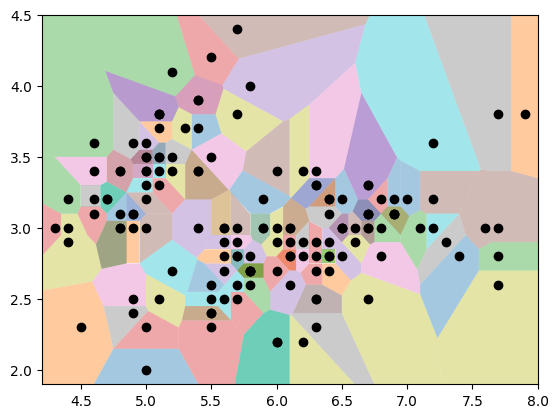

In [34]:
## Plotting Voronoi regions for the Iris dataset

points = []
xpts = np.array(df['sepal length (cm)'])
ypts = np.array(df['sepal width (cm)'])
for i in range(len(xpts)):
  points.append([xpts[i],ypts[i]])
# print(points)
points = np.array(points)
# compute Voronoi tesselation
vor = Voronoi(points)

regions,vertices = voronoi_finite_polygons_2d(vor)

for region in regions:
    polygon = vertices[region]
    plt.fill(*zip(*polygon), alpha=0.4)

plt.plot(points[:,0], points[:,1], 'ko')
plt.xlim(vor.min_bound[0] - 0.1, vor.max_bound[0] + 0.1)
plt.ylim(vor.min_bound[1] - 0.1, vor.max_bound[1] + 0.1)

plt.show()

## Section 2.2: Understanding Decision Boundaries  
So you have seen the Voronoi diagram of the dataset, implemented KNN, and also seen your algorithm's performance in terms of accuracy? Impressive!  
Wouldn't it also be great to know how exactly these 'votes' or neighbours are decided through some kind of visualization?  


### Decision Boundary

While the Voronoi diagram gave us a good idea of the points present in our dataset, to understand how KNN performed on our dataset we can plot decision boundaries. Decision boundaries, as the name suggests, divide the plane into different regions of classification.  

Note that here again, for simplicity, we have only considered first two attributes of the DataFrame (ie, Sepal Length and Sepal Width).  

In [35]:
from matplotlib.colors import ListedColormap
import seaborn as sns


def decision_boundary_plot(x_dec,y_dec,k):
  h = .02  # step size in the mesh

  # Create color maps
  n = len(set(y_dec))
  cmap_light = ListedColormap(['pink', 'green', 'cyan','yellow'][:n])
  cmap_bold = ['pink', 'darkgreen', 'blue','yellow'][:n]

  for weights in ['uniform', 'distance']:
      # we create an instance of Neighbours Classifier and fit the data.
      clf = KNeighborsClassifier(n_neighbors=k, weights=weights)
      clf.fit(x_dec, y_dec)

      # Plot the decision boundary. For that, we will assign a color to each
      # point in the mesh [x_min, x_max]x[y_min, y_max].
      x_min, x_max = x_dec[:, 0].min() - 1, x_dec[:, 0].max() + 1
      y_min, y_max = x_dec[:, 1].min() - 1, x_dec[:, 1].max() + 1
      xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
      Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

      # Put the result into a color plot
      Z = Z.reshape(xx.shape)
      plt.figure(figsize=(8, 6))
      plt.contourf(xx, yy, Z, cmap=cmap_light)

      # Plot also the training points
      sns.scatterplot(x=x_dec[:, 0], y=x_dec[:, 1], hue=y_dec,
                      palette=cmap_bold, alpha=1.0, edgecolor="black")
      plt.xlim(xx.min(), xx.max())
      plt.ylim(yy.min(), yy.max())
      plt.title("Multi-Classification (k = %i, weights = '%s')"% (k, weights))

  plt.show()


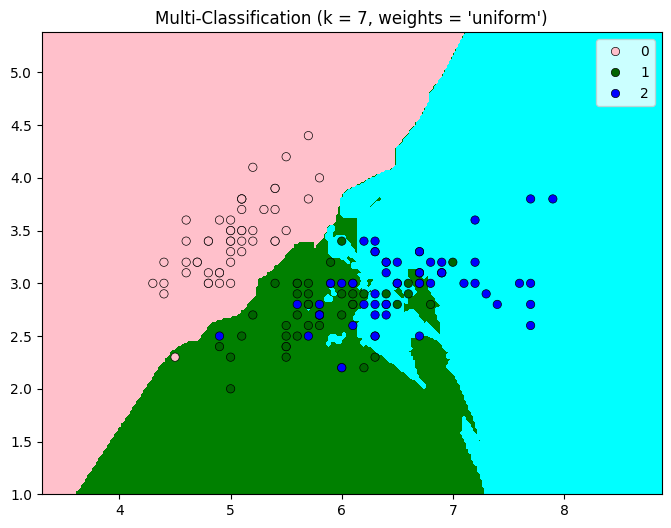

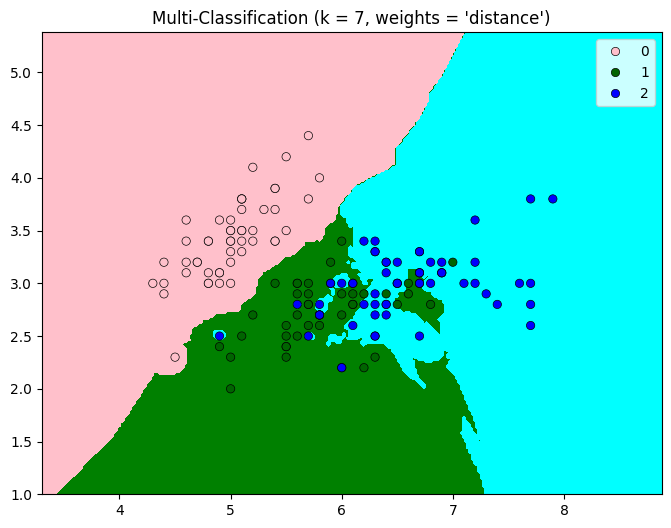

In [36]:
x_pts = X[:,:2]
y_pts = y
decision_boundary_plot(x_pts,y_pts,7)

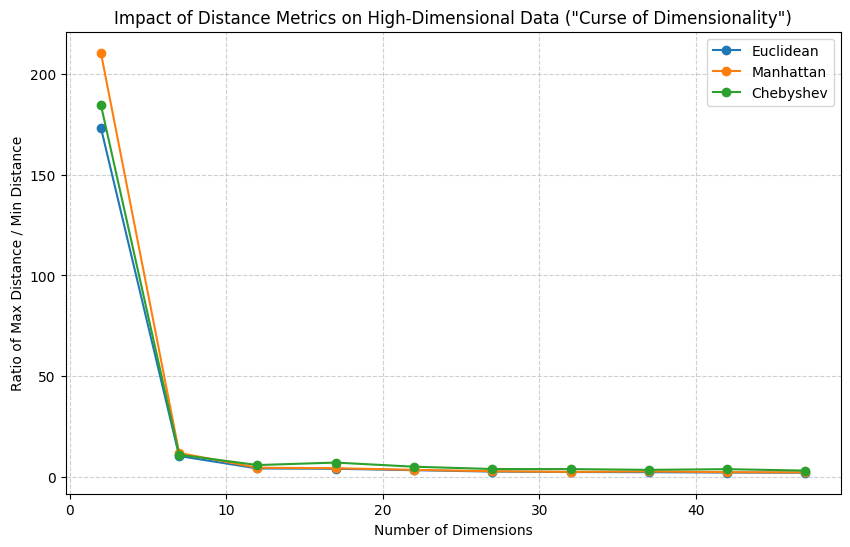

In [37]:
## HOMEWORK TASK 3.1
## Complete the function to analyze distance metrics in high dimensions
## Calculate the ratio of max distance to min distance for each metric

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

def analyze_distance_in_high_dims(max_dim=50, n_points=100):
    """
    Analyze how distance metrics behave in high dimensions.

    Parameters:
    max_dim: Maximum dimensionality to test
    n_points: Number of random points to generate

    Returns:
    Dictionary with results for each metric
    """
    dimensions = list(range(2, max_dim + 1, 5))
    results = {
        'euclidean': [],
        'manhattan': [],
        'chebyshev': []
    }

    for dim in dimensions:
        # Generate random points
        points = np.random.randn(n_points, dim)

        # Calculate all pairwise distances for each metric and calculate ratio
        for metric in results.keys():
            # Map 'manhattan' to 'cityblock' because scipy.spatial.distance.pdist
            # uses 'cityblock' for L1/Manhattan distance.
            pdist_metric = 'cityblock' if metric == 'manhattan' else metric

            distances = pdist(points, metric=pdist_metric)

            min_dist = np.min(distances)
            max_dist = np.max(distances)

            # Avoid division by zero if min_dist is extremely close to 0
            ratio = max_dist / min_dist if min_dist > 0 else 1.0
            results[metric].append(ratio)

    # Plot results
    plt.figure(figsize=(10, 6))
    for metric, ratios in results.items():
        plt.plot(dimensions, ratios, marker='o', label=metric.capitalize())

    plt.title('Impact of Distance Metrics on High-Dimensional Data ("Curse of Dimensionality")')
    plt.xlabel('Number of Dimensions')
    plt.ylabel('Ratio of Max Distance / Min Distance')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

    return results

# Run the analysis
results = analyze_distance_in_high_dims()

## Section 2.3: Confusion Matrix  
In classification problems, a confusion matrix, also known as an error matrix, is a table that allows visualization of the performance of an algorithm, typically a supervised learning one. Each row of the matrix represents the instances in an actual class while each column represents the instances in a predicted class.

In [38]:
from sklearn.metrics import confusion_matrix

In [39]:
# print(confusion_matrix(y_test,predictions))
pd.crosstab(y_test, predictions, rownames=['True'], colnames=['Predicted'], margins=True)

Predicted,0,1,2,All
True,,,,
0,13,0,0,13
1,0,22,0,22
2,0,3,12,15
All,13,25,12,50


Text(0.5, 23.52222222222222, 'Predicted label')

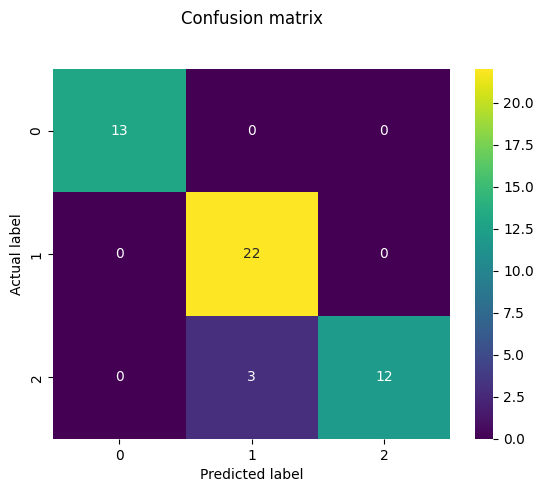

In [40]:
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, predictions)
p = sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="viridis" ,fmt='g')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

## Section 2.4: Classification Report

Precision, Recall, and F1-Score are other metrics besides accuracy that one might look for in an algorithm.  Depending on the use-case, one might consider one metric more important than the other.  

Note: *T-> True, F->False, P->Positive, N->Negative*
    
Mathematically, Accuracy is :  

$Accuracy = \frac{TP+TN}{TP+TN+FP+FN}$  

**Precision**: The accuracy of positive predictions


$Precision = \frac{TP}{TP+FP}$

**Recall**:Fraction of positives that were correctly identified


$Recall = \frac{TP}{TP+FN}$


**F1-score**: Harmonic mean of precision and recall  


$F1 = \frac{2*Precision*Recall}{Precision+Recall} = \frac{2*TP}{2*TP+FP+FN}$  



In [41]:
#import classification_report
from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.88      1.00      0.94        22
           2       1.00      0.80      0.89        15

    accuracy                           0.94        50
   macro avg       0.96      0.93      0.94        50
weighted avg       0.95      0.94      0.94        50



### **Car Evaluation Dataset**

In [42]:
# Upload the Car evaluation data CSV file that has been shared with you.
# Run this cell, click on the 'Choose files' button and upload the file.
from google.colab import files
uploaded = files.upload()

Saving car_evaluation.csv to car_evaluation (1).csv


In [43]:
car_df = pd.read_csv(list(uploaded.keys())[0])
car_df

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good


In [44]:
for x in car_df.columns:
  # print(x)
  le = preprocessing.LabelEncoder()
  le.fit(car_df[x])
  car_df[x]=le.transform(car_df[x])

car_df

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,3,3,0,0,2,2,2
1,3,3,0,0,2,0,2
2,3,3,0,0,1,1,2
3,3,3,0,0,1,2,2
4,3,3,0,0,1,0,2
...,...,...,...,...,...,...,...
1722,1,1,3,2,1,2,1
1723,1,1,3,2,1,0,3
1724,1,1,3,2,0,1,2
1725,1,1,3,2,0,2,1


In [45]:
dataset = car_df.values
X = dataset[:,0:6]
y = np.array(dataset[:,6])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=19)

In [46]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)
score = accuracy_score(y_test, predictions)
print("The accuracy of the classifier on Car evaluation dataset is {:.2f} %".format(100*score))

The accuracy of the classifier on Car evaluation dataset is 89.88 %


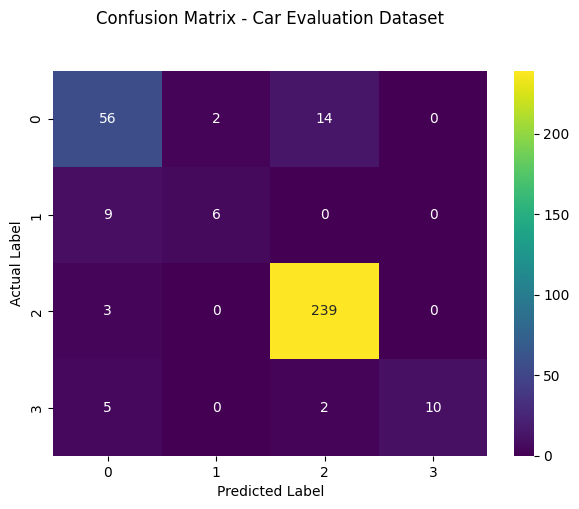

In [47]:
## TASK-3
## Plot a Confusion Matrix for the results of the Car evaluation dataset

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Compute the confusion matrix using your ground truth (y_test) and predictions
cnf_matrix_car = confusion_matrix(y_test, predictions)

# 2. Plot the matrix as a cleanly formatted Seaborn heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cnf_matrix_car, annot=True, fmt='g', cmap='viridis')

plt.title('Confusion Matrix - Car Evaluation Dataset', y=1.1)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [48]:
## TASK-4
## Print a Classification Report for the results of the Car evaluation dataset

from sklearn.metrics import classification_report

# Print the classification report comparing ground truth (y_test) and model predictions
print("Classification Report - Car Evaluation Dataset:\n")
print(classification_report(y_test, predictions))

Classification Report - Car Evaluation Dataset:

              precision    recall  f1-score   support

           0       0.77      0.78      0.77        72
           1       0.75      0.40      0.52        15
           2       0.94      0.99      0.96       242
           3       1.00      0.59      0.74        17

    accuracy                           0.90       346
   macro avg       0.86      0.69      0.75       346
weighted avg       0.90      0.90      0.89       346



Plotting Decision Boundaries for Car Evaluation Dataset...


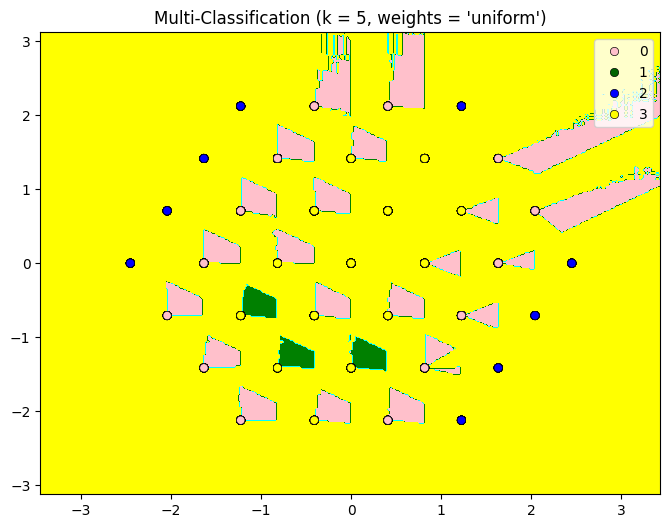

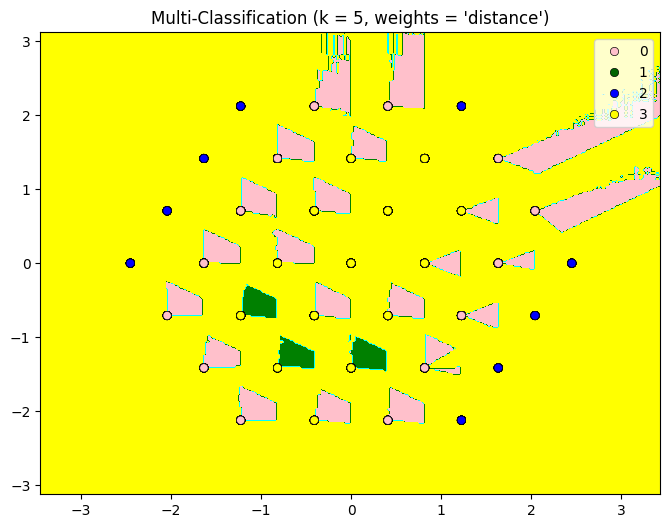

In [49]:
## TASK-5
## Plot the Decision boundary diagram for the classifier of the Car evaluation dataset

from sklearn.decomposition import PCA

# 1. Reduce the Car dataset features to 2D using PCA
pca_car = PCA(n_components=2)
X_car_pca = pca_car.fit_transform(X)

# 2. Plot the decision boundaries (using k=5 as established in Cell 24)
print("Plotting Decision Boundaries for Car Evaluation Dataset...")
decision_boundary_plot(X_car_pca, y, k=5)

In [50]:

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi

# 1. Reduce the Car dataset features to 2D using PCA
pca_car = PCA(n_components=2)
X_car_pca = pca_car.fit_transform(X)

# 2. Compute the Voronoi regions using the 2D PCA points
vor_car = Voronoi(X_car_pca)
# FIXED: Changed vor_finite_polygon_2d to voronoi_finite_polygons_2d
regions_car, vertices_car = voronoi_finite_polygons_2d(vor_car)

# 3. Plot the bounded Voronoi regions
plt.figure(figsize=(8, 6))
for region in regions_car:
    polygon = vertices_car[region]
    plt.fill(*zip(*polygon), alpha=0.4)

# Plot the encoded data points on top
plt.plot(X_car_pca[:, 0], X_car_pca[:, 1], 'ko', ms=3)

# Configure the plot boundaries and labels
plt.xlim(vor_car.min_bound[0] - 0.5, vor_car.max_bound[0] + 0.5)
plt.ylim(vor_car.min_bound[1] - 0.5, vor_car.max_bound[1] + 0.5)
plt.title('Voronoi Diagram - Car Evaluation Dataset (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

KeyError: 80

## **Homework Assignment: Exploring Distance Metrics and KNN**

---

### **Problem 1: Implementing Custom Distance Metrics**

In this exercise, you'll implement distance metrics from scratch to deepen your understanding.

**Task 1.1:** Implement the Minkowski distance formula without using any library functions (except basic numpy operations).

Recall that Minkowski distance is defined as:

$$d(x, x') = \left(\sum_{j=1}^{D} |x_j - x'_j|^p\right)^{1/p}$$

where $p$ is a parameter. When $p=1$, it's Manhattan distance, and when $p=2$, it's Euclidean distance.

In [52]:


## HOMEWORK TASK 1.1
## Implement the Minkowski distance function below
## Test it with p=1 (should match Manhattan) and p=2 (should match Euclidean)
## Expected number of lines: 3-5

def minkowski_distance(x1, x2, p):
    """
    Calculate Minkowski distance between two points.

    Parameters:
    x1, x2: numpy arrays representing points
    p: the order of the Minkowski distance

    Returns:
    float: the Minkowski distance
    """
    # 1. Compute absolute differences, raise to power p, sum them, and take the p-th root
    distance = np.sum(np.abs(x1 - x2) ** p) ** (1 / p)
    return distance

---

### **Problem 2: Visualizing Decision Boundaries**

Understanding how KNN makes predictions is crucial. In this exercise, you'll visualize decision boundaries for different values of K.

**Task 2.1:** Create a function that visualizes the decision boundary of a KNN classifier on 2D data.

**Hint:** You'll need to:
1. Create a mesh grid covering the feature space
2. Train a KNN classifier
3. Predict the class for each point in the mesh
4. Plot the results using `plt.contourf()` for the decision boundary
5. Overlay the training data points

In [51]:
## HOMEWORK TASK 2.1
## Complete the function below to visualize KNN decision boundaries
## The function should create a mesh grid and predict class for each point

from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

def plot_decision_boundary(X, y, k_value, metric='euclidean'):
    """
    Plot the decision boundary for KNN classifier.

    Parameters:
    X: Training data (n_samples, 2)
    y: Training labels
    k_value: Number of neighbors for KNN
    metric: Distance metric to use
    """
    h = .02  # Step size in the mesh

    # 1. Create color maps
    n_classes = len(set(y))
    cmap_light = ListedColormap(['pink', 'green', 'cyan', 'yellow'][:n_classes])
    cmap_bold = ['pink', 'darkgreen', 'blue', 'yellow'][:n_classes]

    # 2. Initialize and fit the KNN Classifier
    clf = KNeighborsClassifier(n_neighbors=k_value, metric=metric)
    clf.fit(X, y)

    # 3. Define the coordinate boundaries of the mesh grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # 4. Generate the complete multi-dimensional mesh grid array matrix
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # 5. Predict classifications for every singular intersection point on the grid
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 6. Plot the underlying color regions
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=cmap_light)

    # 7. Scatter overlay the original training points over their matching regions
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y,
                    palette=cmap_bold, alpha=1.0, edgecolor="black")

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f"KNN Boundary Mapping (k = {k_value}, metric = '{metric}')")
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

**Discussion Questions:**
1. What happens to the decision boundary as K increases? Is it smoother or more irregular?

Ans:When you increase K, you are telling the model to look at the bigger picture rather than stress over individual points. This averaging effect makes the decision boundary much smoother, cleaner, and less irregular. A low K reacts wildly to every single outlier, creating a chaotic and jagged line, whereas a higher K smooths out those bumps to focus on the overall trend.

2. Which K value seems to generalize better without overfitting?

Ans: To get a model that generalizes well without overfitting, you want to avoid the extremes and find a moderate, middle-ground K value. Choosing K=1 overfits by memorizing training noise, while a massive K underfits by completely blurring the classes together. A great starting baseline is the square root of your total data points, which you can then fine-tune using cross-validation.


3. Try changing the metric to 'manhattan' - how does the boundary change?

Ans:Switching to the 'manhattan' metric completely changes the boundary's geometric style, turning it blocky, geometric, and staircase-like. Because Manhattan distance calculates paths along strict right angles—like navigating city blocks—the model abandons organic, rounded curves. Instead, you get a rigid boundary dominated by straight lines, sharp corners, and diamond-shaped regions.

---

### **Problem 3: Impact of Distance Metrics on High-Dimensional Data**

The "curse of dimensionality" affects distance metrics differently. Let's explore this phenomenon.

**Task 3.1:** Create a function that generates random high-dimensional data and compares how different distance metrics behave as dimensionality increases.

**Background:** In high dimensions, the ratio between the maximum and minimum distances between points tends to approach 1, making it harder to distinguish between near and far neighbors. This affects different metrics differently.

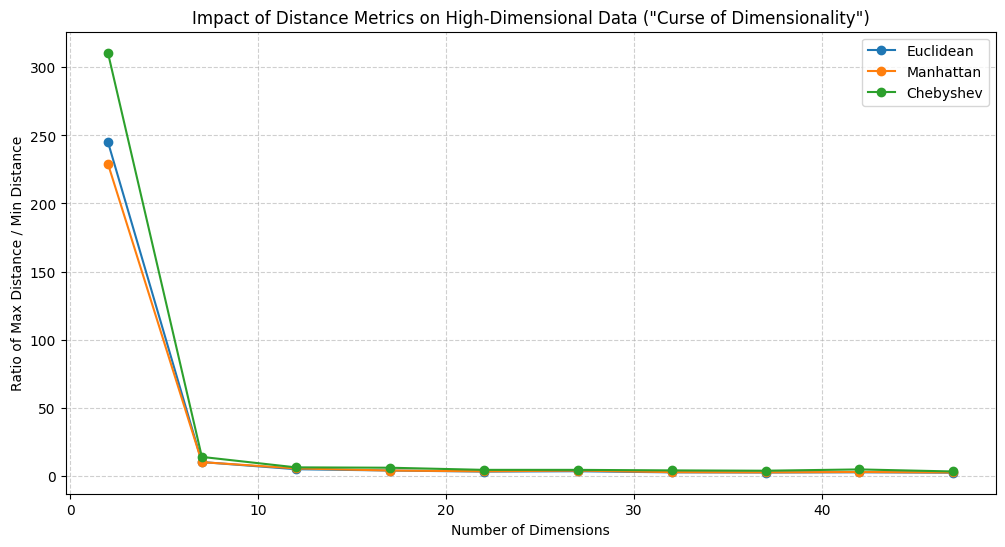

In [53]:

## HOMEWORK TASK 3.1
## Complete the function to analyze distance metrics in high dimensions
## Calculate the ratio of max distance to min distance for each metric

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

def analyze_distance_in_high_dims(max_dim=50, n_points=100):
    """
    Analyze how distance metrics behave in high dimensions.

    Parameters:
    max_dim: Maximum dimensionality to test
    n_points: Number of random points to generate

    Returns:
    Dictionary with results for each metric
    """
    dimensions = list(range(2, max_dim + 1, 5))
    results = {
        'euclidean': [],
        'manhattan': [],
        'chebyshev': []
    }

    for dim in dimensions:
        # Generate random points
        points = np.random.randn(n_points, dim)

        # Calculate all pairwise distances for each metric
        for metric in results.keys():
            # Map 'manhattan' to 'cityblock' because scipy.spatial.distance.pdist
            # uses 'cityblock' for L1/Manhattan distance.
            pdist_metric = 'cityblock' if metric == 'manhattan' else metric

            # Compute all pairwise distances
            distances = pdist(points, metric=pdist_metric)

            # Find min and max distances
            min_dist = np.min(distances)
            max_dist = np.max(distances)

            # Calculate the ratio (avoid division by zero if min_dist is 0)
            ratio = max_dist / min_dist if min_dist > 0 else 1.0

            # Store the ratio of max/min distance
            results[metric].append(ratio)

    # Plot results
    plt.figure(figsize=(12, 6))
    for metric, ratios in results.items():
        plt.plot(dimensions, ratios, marker='o', label=metric.capitalize())

    plt.title('Impact of Distance Metrics on High-Dimensional Data ("Curse of Dimensionality")')
    plt.xlabel('Number of Dimensions')
    plt.ylabel('Ratio of Max Distance / Min Distance')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

    return results

# Run the analysis
results = analyze_distance_in_high_dims()


### Questions to Think About and Answer
1. In the section on Decision boundaries, you must have seen that we ran the KNN algorithm twice: first with the _weights_ set to 'uniform' and then set to 'distance'. Find out the difference between these two.

Ans:With 'uniform' weights, every neighbor gets an equal vote, no matter how close or far it is. Switching to 'distance' weights gives closer neighbors a stronger voice and weakens the influence of far-away points. While this helps the model adapt to dense clusters, it can also make the boundary jagged and prone to overfitting if a noisy outlier lands right next to your query point.


2. What do you think could be the drawbacks of using KNN ?

ANs:The main drawback of KNN is that it gets incredibly slow and memory-heavy as your dataset grows because it must calculate distances to every single training point for every prediction. It also suffers from the "curse of dimensionality," meaning too many features warp distance measurements and confuse the algorithm. Plus, it is highly sensitive to unscaled data, meaning it requires careful preprocessing to work well.

### Useful Resources for further reading
1. Interactive KNN visualization, with class boundaries: http://vision.stanford.edu/teaching/cs231n-demos/knn/  
